In [ ]:
xg_boost ka regression k liye kaam ka flow vesa hi h jesa gradient boosting ka h k phly base model 
bnaya phir residual 
calculate kia or phir inputs and residuals ki base pr DT bnaya , phir output check ki alpha
k saath and then process repeat kia
yani kaam ka flow esa hi h gradient vala h but difference speed/performance etc ko chor kr 
dekhy to DT ki construction m ek
major difference h,,, gradient boosting m tree jesy bnta h vesy yha nhi bnta

yhan tree ek different criterion ki base pr bnta h
bs DT ki production ka crieteria different h, baki sab same h

# step by step calculation

In [ ]:
1---  create base model and calculate residual

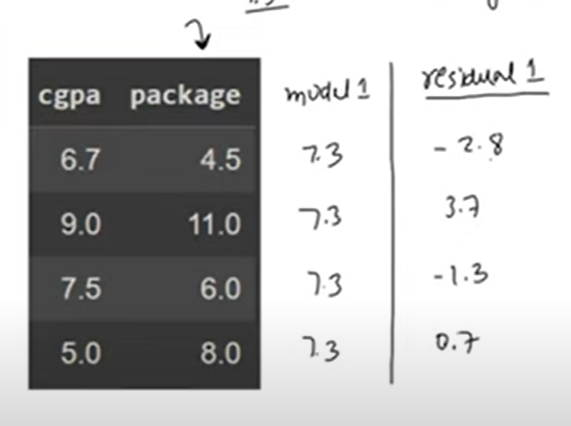

In [1]:
from IPython.display import Image
Image(filename='step1.png', width=300, height=300)

In [ ]:
2---  use cgpa and R1 to create special vala DT

* Ab yhan special vala DT esy bnta h k hm leaf node bnaty hn jis m saary residuals ko dalty hn

* then we calculate similarity measure (jesy vhan gini, entropy etc calculate kia jata h) and
similarity measure formula is:
            similarity measure=(sum of residuals)² / number of residuals+lambda    (lambda is
regularization parameter)

   --> ab is dataset pr residuals ka similarity measure 0.02 aya, hmy is similarity measure ko
increase krny ki koshish krni h

* ab hmy in residuals ko split krna h and spliting criterian vesa hi ho ga jesy hm normal
regression DT m  krty hn k phly data ko sort kr lia then 2 2 data points ko uthan and us ka mean
lena to yhan bhi esa hi h, like below: 

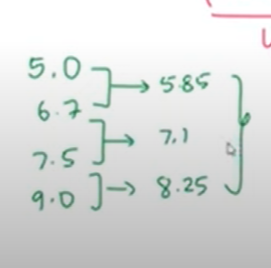

In [1]:
from IPython.display import Image
Image(filename='splitting.png', width=300, height=300)

In [ ]:
ab in teeno values pr hm in residuals ko split kryn gy and end m jo leaf nodes bny un ko dekhyn gy k 
similarity measure kitna aya, yani y dekhna h k kis value pr split kry to similarity measure ziada ay
----->> look at below image: phla split hm n 5.85 pr kia SSL (similarity score of left side) 0.7 aya
and SSR 0.05 aya and is base pr jab gain calculate kia which is (SSL+SSR)-SS(root) to 0.52 aya,
SS(root) s murad SS of all residuals which is 0.02, and we are working with lambda=0 
--> ab jab splitting criterion 8.25 rkha to gain sab s maximum tha

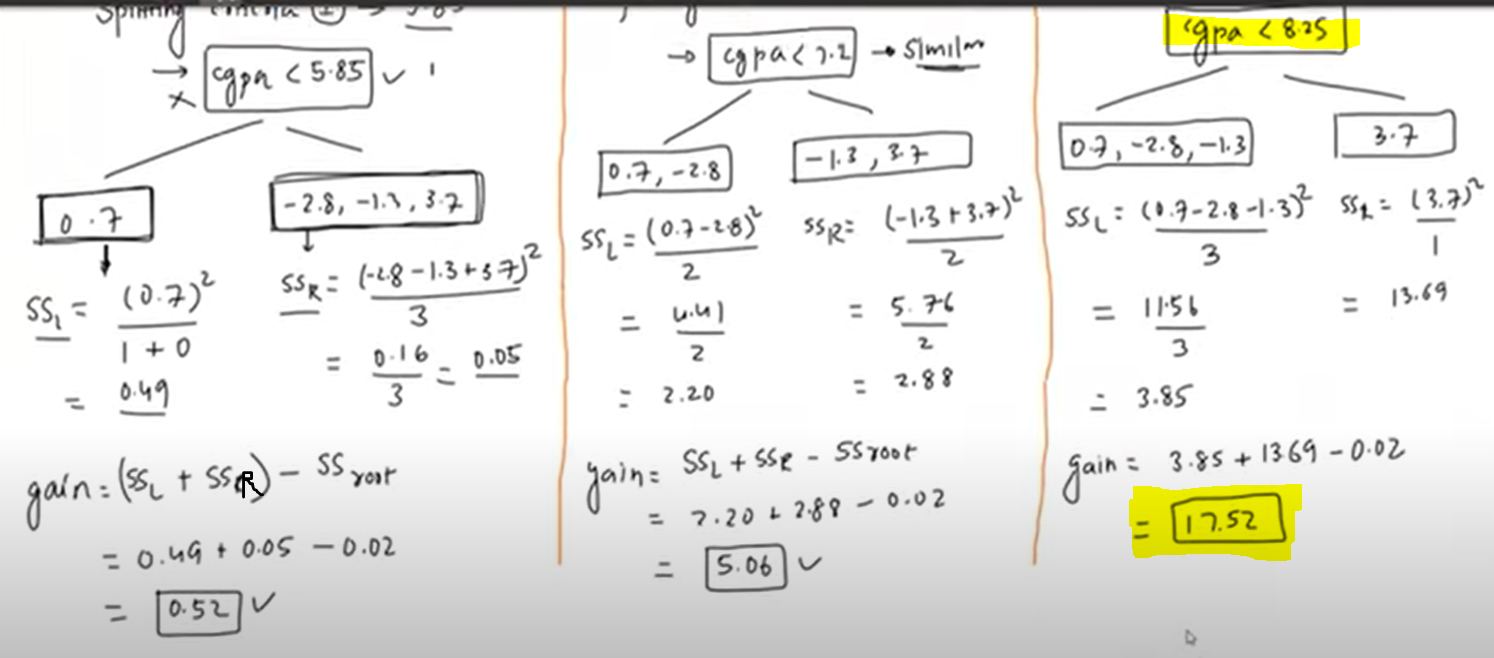

In [4]:
from IPython.display import Image
Image(filename='gain_on_each_split.png', width=400, height=400)

In [ ]:
ab root node ka to pta lag gya k cgpa<8.75 vala h but agli branch ka criterion dekhna h k kis value 
pr slitting ho gi, of course same process hi follow ho ga, yani hm 2 2 points ka mean le kr splitting
kry gy jhan mean gain ziada aya vo final consider kia jay ga: like below

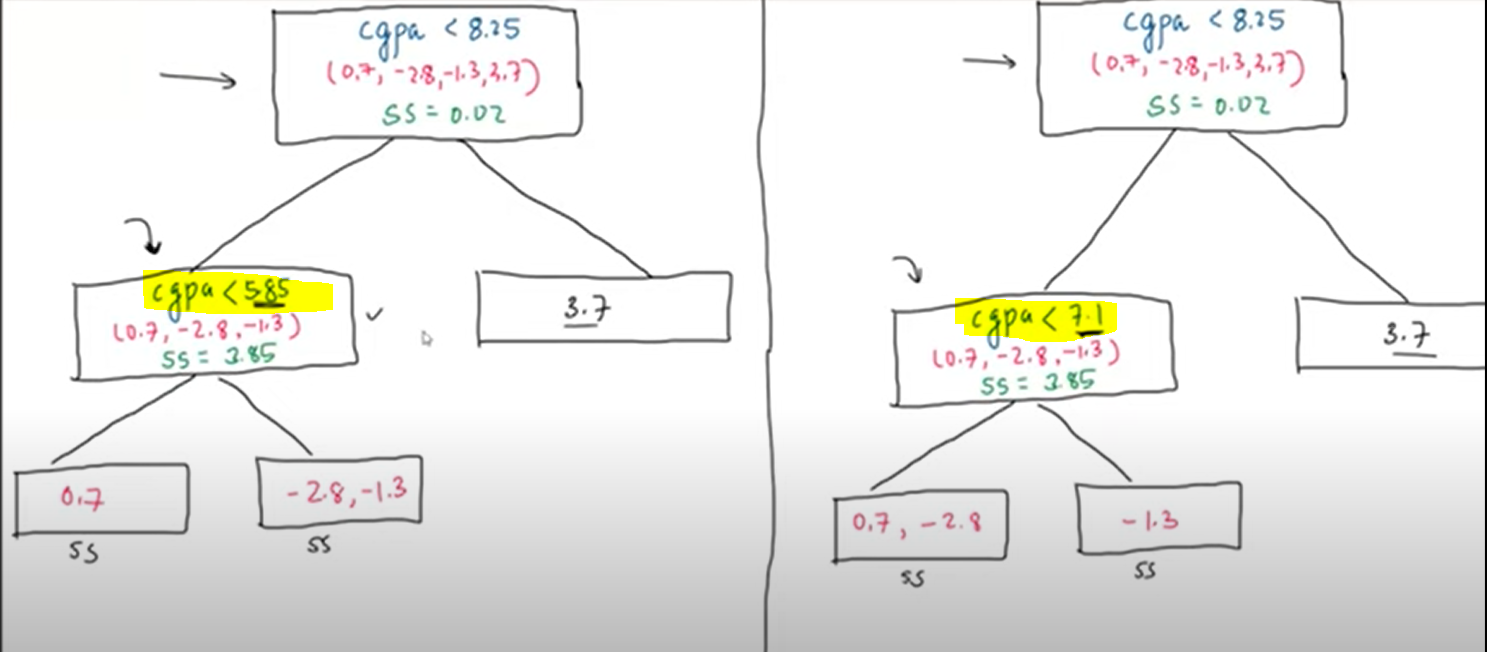

In [5]:
from IPython.display import Image
Image(filename='2nd_splitting.png', width=400, height=400)

In [ ]:
ab 2nd splitting k liye just 2 hi criterion hn, which is 5.85 and 7.1,, ab 5.85 ka gain ziada aya as 
compared to 7.1 so LEFT SIDE vala is our final DT

---->>> vesy XG_Boost m agr 6 data points ek group m a gay to hm mazeed splitting nhi krty, yhan to
just th hi 5 data points is loye practice k liye end tak gay

In [ ]:
* ab hmara final DT ban gya, next hmy leaf nodes ki output nikalni h, like below 

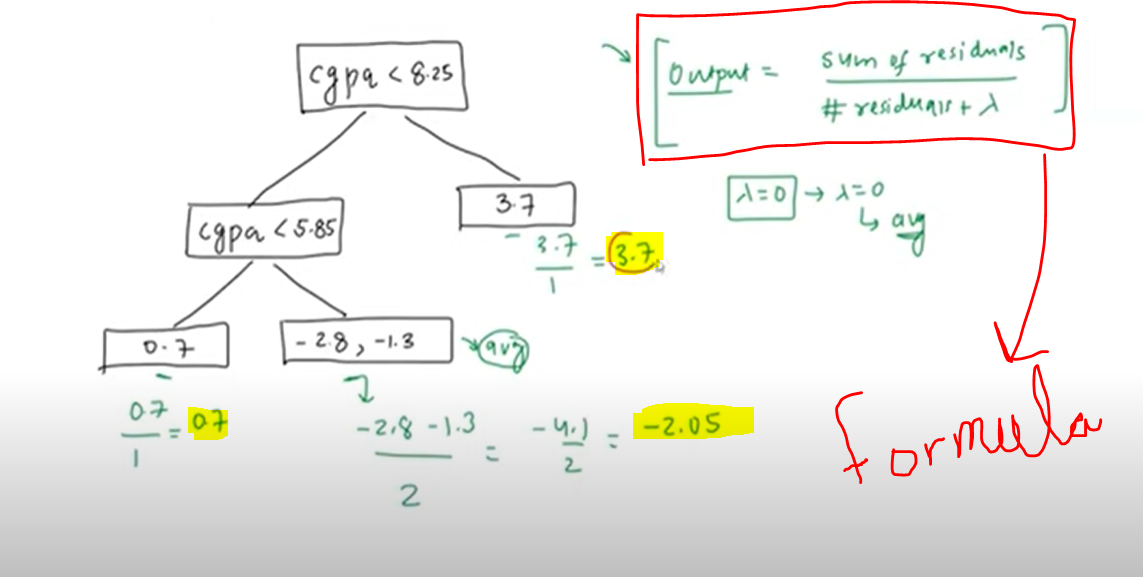

In [6]:
from IPython.display import Image
Image(filename='output_at_leaf_nodes.png', width=400, height=400)

In [ ]:
yani agr kisi ka cgpa 8.25 s jm tha and mazeed 5.85 s bhi km h to us ka package -2.05 ka ho ga and this
is according to DT alone,, hmy combined output calculate krni hoti jesy hm gradient boosting m krty th 
--> yani Base model output + LR * (DT ouput)
LR is learning rate and is ko eta s represent krty in XG_boost and is ka default value 0.3 rehta h

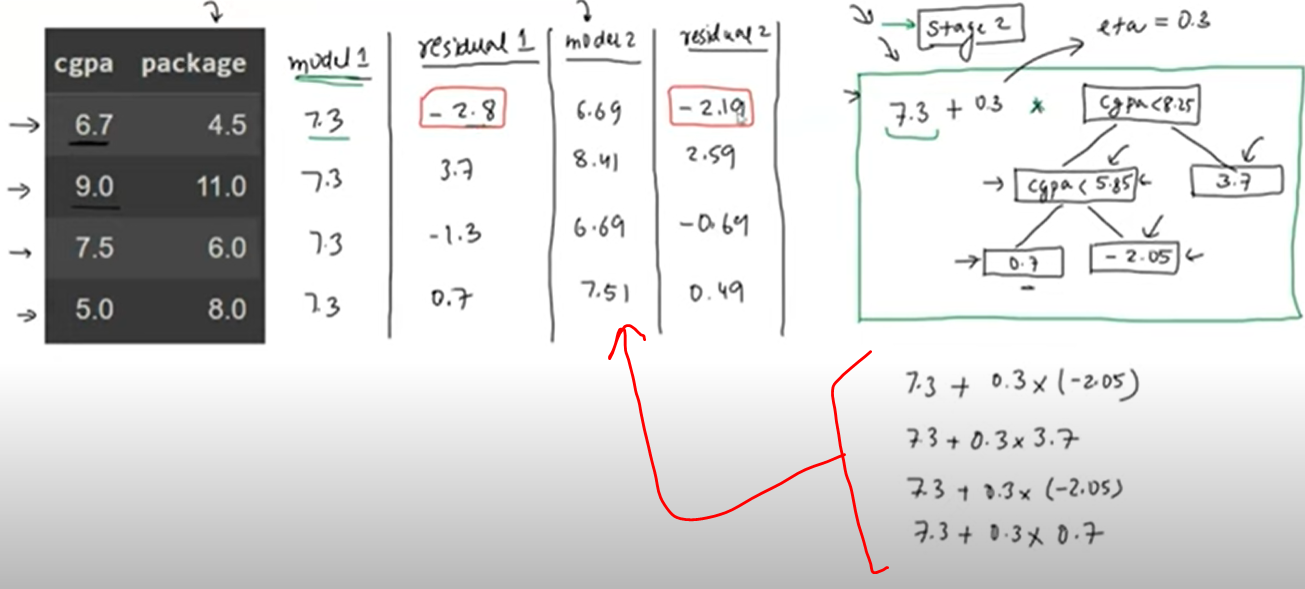

In [7]:
from IPython.display import Image
Image(filename='final_1st_output.png', width=400, height=400)

In [ ]:
look at above figure: 
--- model1 yani base model ka output jo k actually average the
--- residual 1 yani difference of base model output and actuall output and is ki base pr DT bnaya
--- model2 yani combined predicted output of base model(model1) and  1st DT along with learning rate
--- residule 2 yani difference in output of combined predicted output and actuall output, and 
y difference ahista ahista kr k km hota jay ga jesy jesy hm models brhaty jayn gy 

In [ ]:
ab hm next DT bnayn gy between cgpa and residual 2, the goal is to get residual~0

In [ ]:
Making a long story short the process is the same in which we calculate the base model and then
we make a decision tree from the residuals of the base model and the input column. But here the 
difference is actually the making of decision trees. Normally decision trees are made in which
we use the concept of entropy and information gain. Here we also used information gain to determine
which is the best split but we calculate information gain on the basis of similarity score 
concept instead of using entropy. Since we have used similarity score, that's why the information
gain formula is different from the normal formula in which entropy is used. 
    Now the best decision tree is selected on the basis of information gain. After that we will 
make the predictions of our data using the decision tree that we have recently build. 
We will use a specific formula to calculate the predictions using the decision tree. After that we 
will make the combined predicted output, which is actually the output of the base model as well
as the output of the decision tree. We will calculate the error of that model by using the
error of this combined predicted output, which will be equal to residual 2, and then the next
decision tree will be built. By using the input columns as well as the R2 as the output column 